In [1]:
import warnings 
warnings.simplefilter('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import StackingClassifier

In [6]:
df =  pd.read_csv(r"/home/rocky/Documents/Projects/Spam detection/dataset.csv")
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [7]:
data = df.drop(labels=[col for col in ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'] if col in df.columns], axis=1)

In [8]:
data.isnull().sum()

Category    0
Message     0
dtype: int64

In [10]:
data.dtypes

Category    str
Message     str
dtype: object

In [12]:
data['Category'] = data['Category'].map({'spam': 0, 'ham': 1})

In [ ]:
data['Category'].value_counts()

Category
1    4825
0     747
Name: count, dtype: int64

In [15]:
X = data['Message']

Y = data['Category']

In [16]:
X

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                Will Ì_ b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: Message, Length: 5572, dtype: str

In [17]:
Y

0       1
1       1
2       0
3       1
4       1
       ..
5567    0
5568    1
5569    1
5570    1
5571    1
Name: Category, Length: 5572, dtype: int64

In [18]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=3)

In [19]:
print(X.shape)
print(X_train.shape)
print(X_test.shape)

(5572,)
(4457,)
(1115,)


In [25]:
feature_extraction = TfidfVectorizer(min_df = 1, stop_words='english', lowercase = True)

In [27]:
X_train_features = feature_extraction.fit_transform(X_train)
X_test_features = feature_extraction.transform(X_test)

In [28]:
Y_train = Y_train.astype('int')
Y_test = Y_test.astype('int')

# LOGISTIC REGRESSION

In [29]:
lr = LogisticRegression()
lr.fit(X_train_features, Y_train)


lr_train = lr.predict(X_train_features)
lr_test = lr.predict(X_test_features)

        
lr_train_acc = accuracy_score(Y_train, lr_train)
lr_test_acc = accuracy_score(Y_test, lr_test)


lr_precision = precision_score(Y_test, lr_test)
lr_recall = recall_score(Y_test, lr_test)
lr_f1 = f1_score(Y_test, lr_test)


print("Logistic Regression:\n")
print("Training Data Accuracy:", lr_train_acc)
print("Testing Data Accuracy :", lr_test_acc)

print("Precision             :", lr_precision)
print("Recall                :", lr_recall)
print("F1 Score              :", lr_f1)

Logistic Regression:

Training Data Accuracy: 0.9661207089970832
Testing Data Accuracy : 0.9623318385650225
Precision             : 0.959
Recall                : 0.9989583333333333
F1 Score              : 0.9785714285714285


# DECISION TREES

In [30]:
dtrees = DecisionTreeClassifier()
dtrees.fit(X_train_features, Y_train)


dt_train = dtrees.predict(X_train_features)
dt_test = dtrees.predict(X_test_features)


dt_train_acc = accuracy_score(Y_train, dt_train)
dt_test_acc = accuracy_score(Y_test, dt_test)


dt_precision = precision_score(Y_test, dt_test)
dt_recall = recall_score(Y_test, dt_test)
dt_f1 = f1_score(Y_test, dt_test)


print("Decision Tress:\n")
print("Training Data Accuracy:", dt_train_acc)
print("Testing Data Accuracy :", dt_test_acc)

print("Precision             :", dt_precision)
print("Recall                :", dt_recall)
print("F1 Score              :", dt_f1)

Decision Tress:

Training Data Accuracy: 1.0
Testing Data Accuracy : 0.9668161434977578
Precision             : 0.9752832131822863
Recall                : 0.9864583333333333
F1 Score              : 0.9808389435525634


# K NEAREST NEIGHBORS

In [31]:
knn = KNeighborsClassifier()
knn.fit(X_train_features, Y_train)


knn_train = knn.predict(X_train_features)
knn_test = knn.predict(X_test_features)


knn_train_acc = accuracy_score(Y_train, knn_train)
knn_test_acc = accuracy_score(Y_test, knn_test)


knn_precision = precision_score(Y_test, knn_test)
knn_recall = recall_score(Y_test, knn_test)
knn_f1 = f1_score(Y_test, knn_test)


print("K Nearest Neighbors:\n")
print("Training Data Accuracy:", knn_train_acc)
print("Testing Data Accuracy :", knn_test_acc)

print("Precision             :", knn_precision)
print("Recall                :", knn_recall)
print("F1 Score              :", knn_f1)

K Nearest Neighbors:

Training Data Accuracy: 0.9199012788871438
Testing Data Accuracy : 0.905829596412556
Precision             : 0.9014084507042254
Recall                : 1.0
F1 Score              : 0.9481481481481482


# RANDOM FOREST

In [32]:
rf = RandomForestClassifier()
rf.fit(X_train_features, Y_train)


rf_train = rf.predict(X_train_features)
rf_test = rf.predict(X_test_features)


rf_train_acc = accuracy_score(Y_train, rf_train)
rf_test_acc = accuracy_score(Y_test, rf_test)


rf_precision = precision_score(Y_test, rf_test)
rf_recall = recall_score(Y_test, rf_test)
rf_f1 = f1_score(Y_test, rf_test)


print("Random Forest:\n")
print("Training Data Accuracy:", rf_train_acc)
print("Testing Data Accuracy :", rf_test_acc)   
           
print("Precision             :", rf_precision)
print("Recall                :", rf_recall)
print("F1 Score              :", rf_f1)

Random Forest:

Training Data Accuracy: 1.0
Testing Data Accuracy : 0.979372197309417
Precision             : 0.9766022380467956
Recall                : 1.0
F1 Score              : 0.9881626351003603


# STACKING MODEL

In [33]:
estimators = [ ('lr', lr), ('dtree', dtrees), ('knn', knn), ('rf', rf) ]
stack = StackingClassifier(estimators, final_estimator = SVC(kernel='linear'))
stack.fit(X_train_features, Y_train)


stack_train = stack.predict(X_train_features)
stack_test = stack.predict(X_test_features)


stack_train_acc = accuracy_score(Y_train, stack_train)
stack_test_acc = accuracy_score(Y_test, stack_test)


stack_precision = precision_score(Y_test, stack_test)
stack_recall = recall_score(Y_test, stack_test)
stack_f1 = f1_score(Y_test, stack_test)


print("Stacking Classifier:\n")
print("Training Data Accuracy:", stack_train_acc)
print("Testing Data Accuracy :", stack_test_acc)   
           
print("Precision             :", stack_precision)
print("Recall                :", stack_recall)
print("F1 Score              :", stack_f1)

Stacking Classifier:

Training Data Accuracy: 0.9995512676688355
Testing Data Accuracy : 0.9847533632286996
Precision             : 0.9865841073271414
Recall                : 0.9958333333333333
F1 Score              : 0.991187143597719


# Metrics Visualization

In [34]:
train_acc_list = {"LR":lr_train_acc,
                  "DT":dt_train_acc,
                  "KNN":knn_train_acc,
                  "RF":rf_train_acc,
                  "STACK":stack_train_acc}

test_acc_list = {"LR":lr_test_acc,
                  "DT":dt_test_acc,
                  "KNN":knn_test_acc,
                  "RF":rf_test_acc,
                  "STACK":stack_test_acc}

precision_list = {"LR":lr_precision,
                  "DT":dt_precision,
                  "KNN":knn_precision,
                  "RF":rf_precision,
                  "STACK":stack_precision}

recall_list = {"LR":lr_recall,
               "DT":dt_recall,
               "KNN":knn_recall,
               "RF":rf_recall,
               "STACK":stack_recall}

f1_list = {"LR":lr_f1,
               "DT":dt_f1,
               "KNN":knn_f1,
               "RF":rf_f1,
               "STACK":stack_f1}

In [35]:
a1 =  pd.DataFrame.from_dict(train_acc_list, orient = 'index', columns = ["Traning Accuracy"])
a2 =  pd.DataFrame.from_dict(test_acc_list, orient = 'index', columns = ["Testing Accuracy"])
a3 =  pd.DataFrame.from_dict(precision_list, orient = 'index', columns = ["Precision Score"])
a4 =  pd.DataFrame.from_dict(recall_list, orient = 'index', columns = ["Recall Score"])
a5 =  pd.DataFrame.from_dict(f1_list, orient = 'index', columns = ["F1 Score"])

org = pd.concat([a1, a2, a3, a4, a5], axis = 1)
org

,Traning Accuracy,Testing Accuracy,Precision Score,Recall Score,F1 Score
LR,0.966121,0.962332,0.959000,0.998958,0.978571
DT,1.000000,0.966816,0.975283,0.986458,0.980839
KNN,0.919901,0.905830,0.901408,1.000000,0.948148
RF,1.000000,0.979372,0.976602,1.000000,0.988163
STACK,0.999551,0.984753,0.986584,0.995833,0.991187


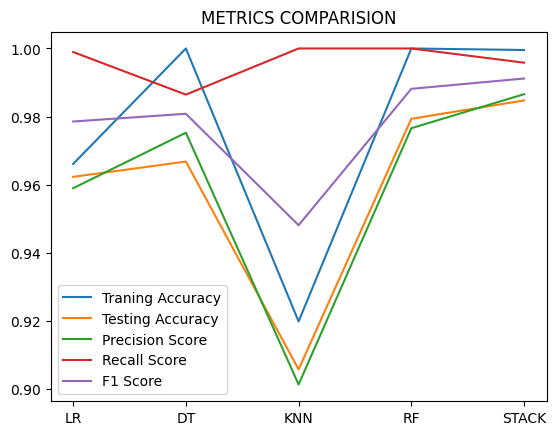

In [36]:
alg = ['LR','DT','KNN','RF','STACK']
plt.plot(alg,a1)
plt.plot(alg,a2)
plt.plot(alg,a3)
plt.plot(alg,a4)
plt.plot(alg,a5)
legend = ['Traning Accuracy', 'Testing Accuracy', 'Precision Score', 'Recall Score', 'F1 Score']
plt.title("METRICS COMPARISION")
plt.legend(legend)
plt.show()

In [ ]:
input_mail = ["""Dear Anubhav Vyas,

Some dreams begin on a couch. Watching the roar of engines on your TV. The lights go out. The cars surge forward. For a moment, you imagine what it would feel like to be there; the speed, the energy, the electric atmosphere of race day.

But dreams like these aren’t fulfilled overnight. They’re built lap by lap.

Small, disciplined investments made regularly through a Systematic Investment Plan* may gradually build the momentum needed to take you from watching the race at home, to experiencing the thrill of race day live. From the screen in your living room to the grandstands of Monaco.

Because every big dream deserves a starting line.

START AN SIP*

Let your dreams pick up speed.

Regards,

Nippon India Mutual Fund

*SIP stands for Systematic Investment Plan, wherein you can regularly invest a fixed amount at periodical intervals and aim for benefits over a period of time through the power of compounding.

Now, you can opt in & start investing on  by just saying ‘Hi’ to us on 843 3938 264 from your registered mobile number. Say Hi Now!

"""]

input_mail_features = feature_extraction.transform(input_mail)

prediction = stack.predict(input_mail_features)

if(prediction == 0):
    print("SPAM MAIL")
else:
    print("HAM MAIL")

HAM MAIL
